In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sdk1810/playtennis")

print("Path to dataset files:", path)

100%|██████████| 291/291 [00:00<00:00, 244kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sdk1810/playtennis/versions/1


In [6]:
import pandas as pd

# Load dataset
file_path = "/content/PlayTennis.csv"  # Update the filename if needed
df = pd.read_csv(file_path)

# Display first few rows
print(df.head())


    outlook  temp humidity  windy play
0     sunny   hot     high  False   no
1     sunny   hot     high   True   no
2  overcast   hot     high  False  yes
3     rainy  mild     high  False  yes
4     rainy  cool   normal  False  yes


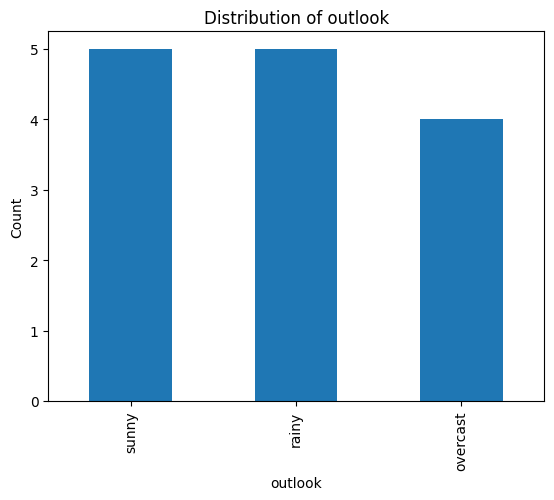

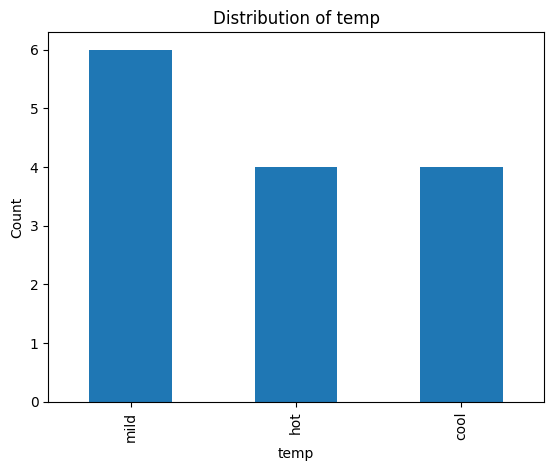

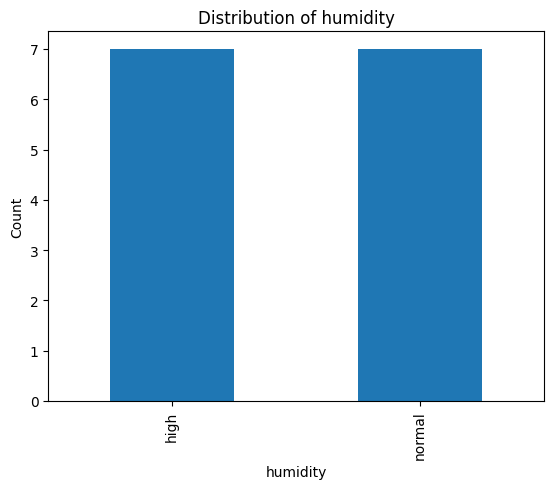

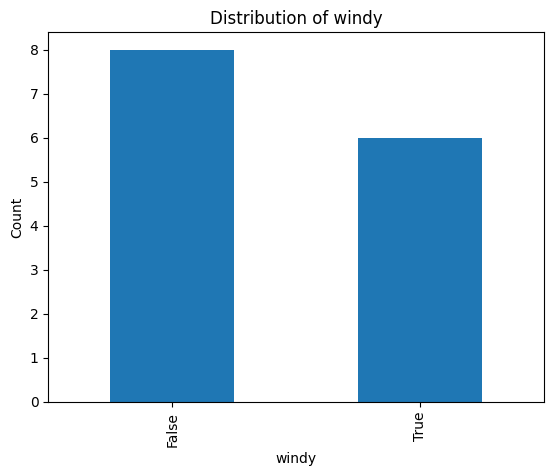

In [7]:
# Visualizing categorical features
for column in df.columns[:-1]:  # Ignore the target column
    df[column].value_counts().plot(kind="bar", title=f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()


In [9]:
le = LabelEncoder()
for column in df.columns:
    df[column] = le.fit_transform(df[column])

# Splitting independent (X) and dependent (y) variables
X = df.drop(columns=['play'])  # Features
y = df['play']  # Target


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
# Train Decision Tree (ID3)
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy')

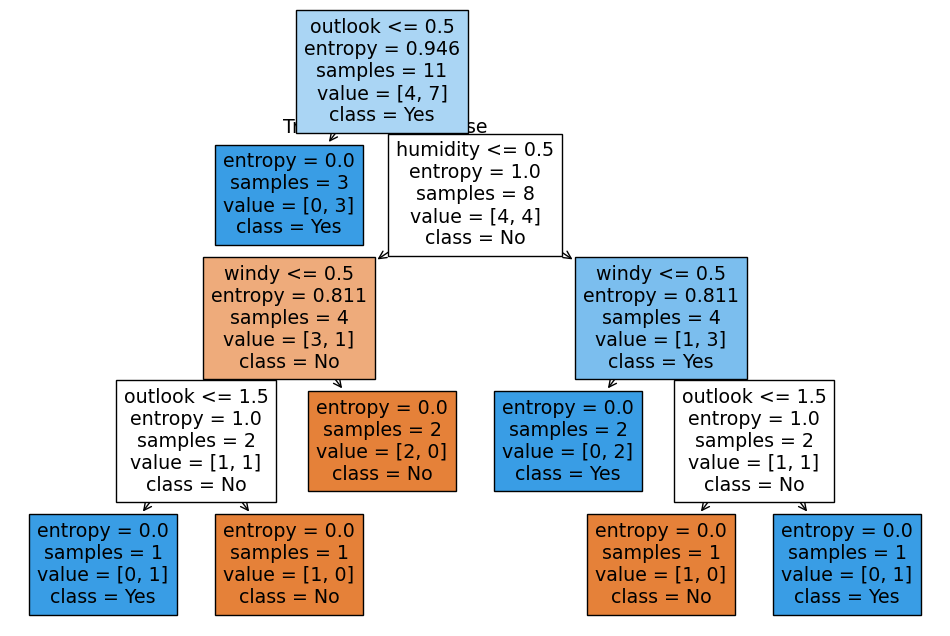

In [12]:
plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True)
plt.show()


In [13]:
# Predictions
y_pred = clf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 1.00


In [15]:
from sklearn.metrics import accuracy_score

# Predictions on training and test sets
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

# Compute accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")


Training Accuracy: 1.00
Testing Accuracy: 1.00


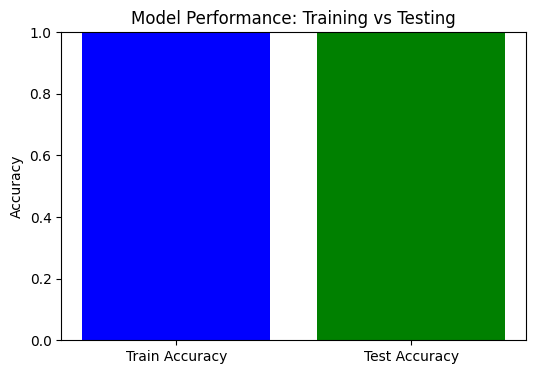

In [16]:
import numpy as np

# Bar plot of training vs testing accuracy
plt.figure(figsize=(6,4))
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_accuracy, test_accuracy], color=['blue', 'green'])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Performance: Training vs Testing")
plt.show()


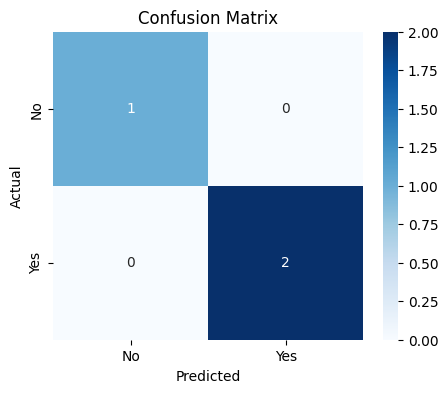

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
